# 1. COMPRENDER EL PROBLEMA Y EL CASO PRÁCTICO.


<table>
  <tr><td>
    <img src="https://drive.google.com/uc?id=15eGnAbma5Q_j9CZZKi46Gh3-EpgSWYOV"
         alt="Fashion MNIST sprite"  width="1000">
  </td></tr>
  <tr><td align="center">
    <b>Figura 1. Clasificación de Enfermedades utilizando Deep Learning 
  </td></tr>
</table>


![alt text](https://drive.google.com/uc?id=1t-Q7JllEobw8YwV3wcTuMA12J9JArfwp)

![alt text](https://drive.google.com/uc?id=1pNAshUhBxksQcrTfulYmUKXUPOmWbXb0)

# 2. IMPORTAR LIBRERÍAS Y CONJUNTO DE DATOS.

## 2.1 Instalar opencv-python.

In [1]:
# Solo se instala una vez, así que lo dejaré como comentario.
# !pip install opencv-python

## 2.2 Importe de librerías.

In [2]:
import os # librería sistema operativo
import cv2 # librería para tratar imágenes
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, optimizers # capas y optimizadores
from tensorflow.keras.applications.resnet50 import ResNet50 # red neuronal residual para facilitar el trabajo (con pesos ya entrenados y ya cargados)
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout # capas estándar para imágenes
from tensorflow.keras.models import Model, load_model # modelo y carga del modelo de tensorflow
from tensorflow.keras import backend as K # más adelante sabré para qué es
from tensorflow.keras.preprocessing.image import ImageDataGenerator # carga las imágenes en lotes desde la carpeta de trabajo para poder entrenar de grupo en grupo
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler # callbacks para seleccionar el mejor modelo de los epochs
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


## 2.3 Guardar la ubicación (directorio) de nuestras imágenes de entrenamiento. 

In [3]:
XRay_Directory = 'C:/Users/Danko/Dropbox/00 Programacion/00_portafolio/proyectos/04_proyecto_operations_department/Dataset'

In [4]:
## 2.4 Listar las carpetas de dicho directorio.

In [5]:
os.listdir(XRay_Directory)

['0', '1', '2', '3']

## 2.4 Cargar las imágenes con ImageGenerator.
#### ImageGenerator sirve para: 1. Cargar imágenes para generar datos de imágenes de tensores. 2. Normalizar las imágenes. 3. Realizar lotes de entrenamiento de 40 en 40 imágenes. 4. Usar el 20% de los datos para la validación cruzada posterior.

In [6]:
image_generator = ImageDataGenerator(rescale=1./255, validation_split=0.2)
# primer parametro para reescalar las imágenes y segundo parámetro para dividir entreno de testing
# usaremos mucho la validación cruzada para no tener problemas de over fitting

## 2.5 Definir el generador para entrenar y el generador para validar.

#### La función flow_from_directory sirve para no agregar todas las imagenes en memoria. Para esto creamos un flujo de datos para el entrenamiento y especificamos las condiciones para ir cargando las imágenes a tensorflow a medida que este las vaya necesitando para el proceso de validación.

In [7]:
train_generator = image_generator.flow_from_directory(batch_size= 40, directory= XRay_Directory, shuffle = True,
                                                     target_size = (256, 256), class_mode = 'categorical',
                                                     subset='training')
# Parámetros:
# 1. bach: cargamos las imágenes en lotes de 40 en 40 para la fase de entrenamiento.
# 2. directory: cargar el directorio.
# 3. shuffle: aleatorizar la muestra entre todas y cada una de las características que se quieran analizar entre las 4
# carpetas o categorías.
# 4. target: que todas las imágenes tengan el mismo tamaño.
# 5. class_model: explicita qué tipo de problema usaremos, puede ser "categorical", "binary", "sparse", "input" or None.
# Por default es "categorical". Determina el tipo de etiqueta de matriz que retornará.
# 6. subset: como cargaremos el subconjunto de entrenamiento y el de test con la misma función, especificaremos qué
# subset se usará

Found 428 images belonging to 4 classes.


In [8]:
train_generator = image_generator.flow_from_directory(batch_size= 40, directory= XRay_Directory, shuffle = True,
                                                     target_size = (256, 256), class_mode = 'categorical',
                                                     subset='validation')

Found 104 images belonging to 4 classes.


## 2.6 Generar un lote de 40 imágenes con sus etiquetas.

In [9]:
train_images, train_labels = next(train_generator)

In [10]:
train_images.shape

(40, 256, 256, 3)

In [11]:
train_labels.shape

(40, 4)

In [12]:
train_labels

array([[0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.]],

In [13]:
# Traducción de cada Etiqueta
label_names = {0: 'COVID-19', 1: 'Normal', 2: 'Neumonía Vírica', 3: 'Neumonía Bacteriana'}

# 3. VISUALIZACIÓN DEL DATASET.

## 3.1 Matriz de 36 imágenes junto a sus etiquetas

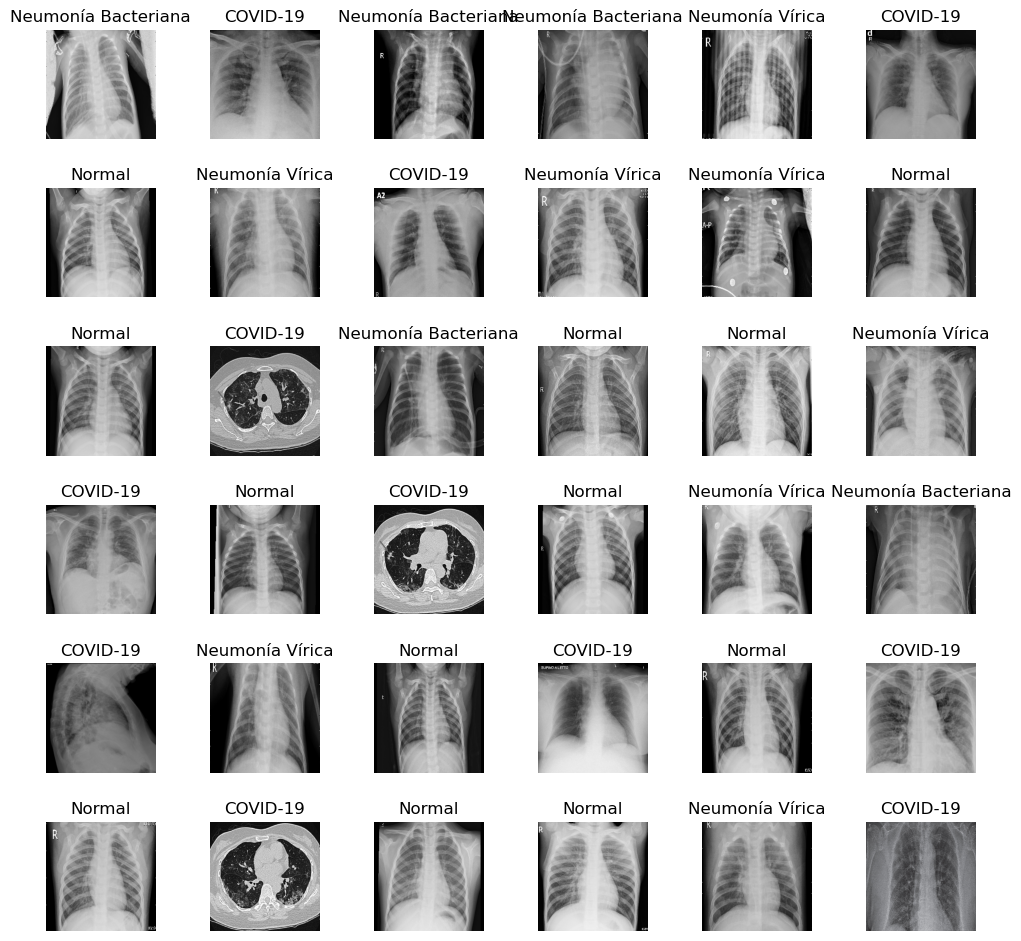

In [17]:
# mostraremos una matriz de las imágenes para que nuestro modelo pueda verlas y aprender de ellas
L = 6
W = 6

fig, axes = plt.subplots(L, W, figsize = (12,12)) # figura y el eje mediante un sub-gráfico
axes = axes.ravel() # aplanamos el eje de dibujo para que se muestren las imágenes una detras de la otra
# asi al acceder a una posición mediante un bucle for, se ajustará para mostrar en forma de matriz bidimensional.
for i in np.arange(0,L*W):
    axes[i].imshow(train_images[i]) # pinta la imagen i-ésima
    axes[i].set_title(label_names[np.argmax(train_labels[i])]) # título desde las etiquetas label_names, usando
    # la función argmax, que me entrega la posición del valor más alto, es decir, el número uno que se encuetra
    # entre los tres ceros. 
    axes[i].axis('off') #borramos los ejes ya que no es un gráfico cartesiano.
    
    plt.subplots_adjust(wspace = 0.5) # ajusta el espaciado entre las imágenes

# TAREA #4: ENTENDER LA TEORÍA Y LA INTUICIÓN DETRAS DE LAS REDES NEURONALES PROFUNDAS

![alt text](https://drive.google.com/uc?id=1e4bFs8Fh2Bp4ueRi9Q9SASRWZ2SwShJX)

![alt text](https://drive.google.com/uc?id=1zsKnK9bQVjUt5Z38gEK3qnIoafRR6i1c)

![alt text](https://drive.google.com/uc?id=1mL13x1d9uAItMFwtV_9r-fKqQp8DjfQo)

![alt text](https://drive.google.com/uc?id=1-se5iR8RsZ4Bold3MK60hDpL0qky7H97)

# TEORÍA #5: ENTENDER LA TEORÍA Y LA INTUICIÓN DETRÁS DEL APRENDIZAJE POR TRANSFERENCIA

![alt text](https://drive.google.com/uc?id=1ypOE6WINmjunchutKTSUbx4FCzuYUyqC)

![alt text](https://drive.google.com/uc?id=16Rhq_7flyuy5oS1vEJ7p3l1Y8irU7Zwg)

![alt text](https://drive.google.com/uc?id=1hCdV7lmgADpw8jV7nf0KO3mMzIMuMZDM)

![alt text](https://drive.google.com/uc?id=1gHDvwWJBBD5d94HPpSydQLb6pjTfknrK)

# TAREA #6: IMPORTAR EL MODELO CON PESOS PRE ENTRENADOS

In [15]:
# Congelar el modelo hasta las últimas etapas - 4 y llevar a cabo un re entrenamiento -5 


# TAREA #7: CONSTRUIR Y ENTRENAR UN MODELO DE DEEP LEARNING

In [16]:
# Usar la parada temprana (early stopping) para salir del entrenamiento si la pérdida en la validación no disminuye incluso después de ciertas épocas (paciencia)


# Almacenar el mejor modelo con la menor pérdida en la validación

# TAREA #8: EVALUAR EL MODELO DE DEEP LEARNING ENTRENADO

# BUEN TRABAJO! PUEDES ESTAR ORGULLOSO DE TUS NUEVAS HABILIDADES ADQUIRIDAS
